In [2]:
import wandb
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from typing import Any, Callable, Mapping, Optional, Text, Tuple, Union, Iterable
import numpy as np
import plotly.graph_objects as go
from absl import logging
import hydra
import matplotlib.patches as mpatches

sns.set_theme()


In [3]:
import wandb
from dm_env import specs
import uuid
from collections import OrderedDict

from helpers import modulators

In [76]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator, LogLocator

In [4]:
from hydra.core.global_hydra import GlobalHydra
from omegaconf import DictConfig, OmegaConf

# Clear existing Hydra instance if already initialized
if GlobalHydra.instance().is_initialized():
    GlobalHydra.instance().clear()

# Initialize Hydra and load the config directly
hydra.initialize(config_path="../", version_base=None)
cfg = hydra.compose(config_name="full_train_miniworld_slippery_fix")

In [5]:
if cfg.logging.mode == "full_train":
    experiment = cfg.domain.train.logging.experiment

elif cfg.logging.mode == "test":
    experiment = cfg.domain.test.logging.experiment

elif cfg.logging.mode == "pretrain":
    experiment = cfg.domain.pretrain.logging.experiment
elif cfg.logging.mode == "full_train_slippery":
    experiment = cfg.domain.train.logging.experiment + "_slippery"

elif cfg.logging.mode == "full_train_slippery_fix":
    experiment = cfg.domain.train.logging.experiment + "_slippery_fix"

else:
    raise ValueError("Invalid logging mode: {}".format(cfg.logging.mode))

In [6]:
moving_average_window = 10 # window size for moving average

In [7]:
api = wandb.Api()

project_name = "continual_rl" + "_" + cfg.logging.mode + "_" + experiment
entity = "crlmsf"
runs = api.runs(entity + "/" + project_name)

summary_list, config_list, name_list = [], [], []

logging.info("inside avg_episode_return")

num_of_runs = len(runs)
print("num_of_runs:", num_of_runs)

num_of_runs: 259


In [8]:
for idx, run in enumerate(runs):
    # .summary contains the output keys/values
    #  for metrics such as accuracy.
    #  We call ._json_dict to omit large files
    # summary_list.append(run.summary._json_dict)
    if idx % 10 == 0:
        print("idx:", idx)

    if "best" not in run.tags:
        continue

    if run.config["agent_feature_dim"] != 256:
        continue

    print(run.config["agent_name"])

    avg_episode_returns_history = run.scan_history(keys=["eval/avg_episode_returns"])
    avg_episode_return = [
        row["eval/avg_episode_returns"] for row in avg_episode_returns_history
    ]

    avg_episode_length_history = run.scan_history(keys=["eval/avg_episode_length"])
    avg_episode_length = [
        row["eval/avg_episode_length"] for row in avg_episode_length_history
    ]

    steps_history = run.scan_history(keys=["eval/steps"])

    steps = [row["eval/steps"] for row in steps_history]

    task_history = run.scan_history(keys=["train/task"])
    task = [row["train/task"] for row in task_history]


    # if len(steps) < num_data_points_plotting:
    #     print("len(steps) < num_data_points_plotting")
    #     print("seed: ", run.config["agents_seed"])
    #     print("agent_name: ", run.config["agent_name"])
    #     continue

    print("len(steps): ", len(steps))
    print("len(avg_episode_return): ", len(avg_episode_return))
    print("len(avg_episode_length): ", len(avg_episode_length))

    # combine steps and avg_episode_returns into a dictionary using train/steps and train/avg_episode_returns
    # as the keys.
    temp = dict()
    temp["eval/steps"] = steps
    temp["eval/episode_return"] = avg_episode_return
    temp["eval/avg_episode_length"] = avg_episode_length
    temp["train/task"] = task

    temp["eval/mvg_avg_episode_length"] = np.convolve(
        temp["eval/avg_episode_length"],
        np.ones((moving_average_window,))
        / moving_average_window,
        mode="valid",
    )

    temp["eval/mvg_avg_episode_length"] = np.pad(
        temp["eval/mvg_avg_episode_length"],
        (moving_average_window - 1, 0),
        "constant",
        constant_values=cfg.domain.max_episode_length,
    )

    if "attention" in run.config["agent_name"]:
        #attention 1
        attention_8_history_1 = run.scan_history(keys=["train/attention_outputs_u8_mean"])
        attention_8_1 = [row["train/attention_outputs_u8_mean"] for row in attention_8_history_1]

        attention_7_history_1 = run.scan_history(keys=["train/attention_outputs_u7_mean"])
        attention_7_1 = [row["train/attention_outputs_u7_mean"] for row in attention_7_history_1]

        attention_6_history_1 = run.scan_history(keys=["train/attention_outputs_u6_mean"])
        attention_6_1 = [row["train/attention_outputs_u6_mean"] for row in attention_6_history_1]

        attention_5_history_1 = run.scan_history(keys=["train/attention_outputs_u5_mean"])
        attention_5_1 = [row["train/attention_outputs_u5_mean"] for row in attention_5_history_1]

        attention_4_history_1 = run.scan_history(keys=["train/attention_outputs_u4_mean"])
        attention_4_1 = [row["train/attention_outputs_u4_mean"] for row in attention_4_history_1]

        attention_3_history_1 = run.scan_history(keys=["train/attention_outputs_u3_mean"])
        attention_3_1 = [row["train/attention_outputs_u3_mean"] for row in attention_3_history_1]

        attention_2_history_1 = run.scan_history(keys=["train/attention_outputs_u2_mean"])
        attention_2_1 = [row["train/attention_outputs_u2_mean"] for row in attention_2_history_1]

        attention_1_history_1 = run.scan_history(keys=["train/attention_outputs_u1_mean"])
        attention_1_1 = [row["train/attention_outputs_u1_mean"] for row in attention_1_history_1]

        attention_0_history_1 = run.scan_history(keys=["train/attention_outputs_u0_mean"])
        attention_0_1 = [row["train/attention_outputs_u0_mean"] for row in attention_0_history_1]

        # attention_8_1.insert(0, 0)
        # attention_7_1.insert(0, 0)
        # attention_6_1.insert(0, 0)
        # attention_5_1.insert(0, 0)
        # attention_4_1.insert(0, 0)
        # attention_3_1.insert(0, 0)
        # attention_2_1.insert(0, 0)
        # attention_1_1.insert(0, 0)
        # attention_0_1.insert(0, 0)

        temp["train/attention_outputs_u8_mean"] = attention_8_1
        temp["train/attention_outputs_u7_mean"] = attention_7_1
        temp["train/attention_outputs_u6_mean"] = attention_6_1
        temp["train/attention_outputs_u5_mean"] = attention_5_1
        temp["train/attention_outputs_u4_mean"] = attention_4_1
        temp["train/attention_outputs_u3_mean"] = attention_3_1
        temp["train/attention_outputs_u2_mean"] = attention_2_1
        temp["train/attention_outputs_u1_mean"] = attention_1_1
        temp["train/attention_outputs_u0_mean"] = attention_0_1


    else:
        zeros_list = [0] * len(steps)
        temp["train/attention_outputs_u8_mean"] = zeros_list
        temp["train/attention_outputs_u7_mean"] = zeros_list
        temp["train/attention_outputs_u6_mean"] = zeros_list
        temp["train/attention_outputs_u5_mean"] = zeros_list
        temp["train/attention_outputs_u4_mean"] = zeros_list
        temp["train/attention_outputs_u3_mean"] = zeros_list
        temp["train/attention_outputs_u2_mean"] = zeros_list
        temp["train/attention_outputs_u1_mean"] = zeros_list
        temp["train/attention_outputs_u0_mean"] = zeros_list

    print("len attention_0_1: ", len(temp["train/attention_outputs_u0_mean"]))
    print("len attention_1_1: ", len(temp["train/attention_outputs_u1_mean"]))
    print("len attention_2_1: ", len(temp["train/attention_outputs_u2_mean"]))
    print("len attention_3_1: ", len(temp["train/attention_outputs_u3_mean"]))
    print("len attention_4_1: ", len(temp["train/attention_outputs_u4_mean"]))
    print("len attention_5_1: ", len(temp["train/attention_outputs_u5_mean"]))
    print("len attention_6_1: ", len(temp["train/attention_outputs_u6_mean"]))
    print("len attention_7_1: ", len(temp["train/attention_outputs_u7_mean"]))
    print("len attention_8_1: ", len(temp["train/attention_outputs_u8_mean"]))


    summary_list.append(temp)
    del temp

    # .config contains the hyperparameters.
    #  We remove special values that start with _.
    config_list.append(
        {k: v for k, v in run.config.items() if not k.startswith("_")}
    )

    # .name is the human-readable name of the run.
    name_list.append(run.name)

idx: 0
simple_sf_agent
len(steps):  200
len(avg_episode_return):  200
len(avg_episode_length):  200
len attention_0_1:  200
len attention_1_1:  200
len attention_2_1:  200
len attention_3_1:  200
len attention_4_1:  200
len attention_5_1:  200
len attention_6_1:  200
len attention_7_1:  200
len attention_8_1:  200
simple_sf_agent
len(steps):  200
len(avg_episode_return):  200
len(avg_episode_length):  200
len attention_0_1:  200
len attention_1_1:  200
len attention_2_1:  200
len attention_3_1:  200
len attention_4_1:  200
len attention_5_1:  200
len attention_6_1:  200
len attention_7_1:  200
len attention_8_1:  200
simple_sf_agent
len(steps):  200
len(avg_episode_return):  200
len(avg_episode_length):  200
len attention_0_1:  200
len attention_1_1:  200
len attention_2_1:  200
len attention_3_1:  200
len attention_4_1:  200
len attention_5_1:  200
len attention_6_1:  200
len attention_7_1:  200
len attention_8_1:  200
simple_sf_agent
len(steps):  200
len(avg_episode_return):  200
len

In [27]:
runs_df = pd.DataFrame(
        {"summary": summary_list, "config": config_list, "name": name_list}
    )

# create a new column using agent_name
runs_df["agent_name"] = runs_df["config"].apply(lambda x: x["agent_name"])

# # create a new column using agents_seed
runs_df["agent_seed"] = runs_df["config"].apply(lambda x: x["agent_seed"])

runs_df["domain_slippery_prob"] = runs_df["config"].apply(lambda x: x["domain_slippery_prob"])

In [28]:
agents_new_names = {
    "dqn": "DQN",
    "DQN_consolidation_params_continuous": "DQN + SC",
    "simple_sf_agent": "SF",
    "sf_consolidation_params_continuous": "SF + SC (Ours)",
    "dqn_online_ewc": "DQN + EWC",
    "simple_sf_online_ewc": "SF + EWC",
    "sf_consolidation_params_continuous_softmax_attention_diff_unique": "SF + SC + Attention (Ours)",
    "DQN_plasticity_injection" : "DQN + P-last",
    "dqn_cbp" : "DQN + CBP",
}

In [29]:
# replace all "ddpg" in agent_name column with "DDPG"
runs_df["agent_name"] = runs_df["agent_name"].replace(
    "dqn", agents_new_names["dqn"]
)

In [30]:
# replace all "ddpg" in agent_name column with "DDPG"
runs_df["agent_name"] = runs_df["agent_name"].replace(
    "dqn_cbp", agents_new_names["dqn_cbp"]
)

In [31]:
runs_df["agent_name"] = runs_df["agent_name"].replace(
    "simple_sf_agent", agents_new_names["simple_sf_agent"]
)

In [32]:
runs_df["agent_name"] = runs_df["agent_name"].replace(
    "DQN_consolidation_params_continuous", agents_new_names["DQN_consolidation_params_continuous"]
)

In [33]:
runs_df["agent_name"] = runs_df["agent_name"].replace(
    "sf_consolidation_params_continuous", agents_new_names["sf_consolidation_params_continuous"]
)

In [34]:
runs_df["agent_name"] = runs_df["agent_name"].replace(
    "dqn_online_ewc", agents_new_names["dqn_online_ewc"]
)

In [35]:
runs_df["agent_name"] = runs_df["agent_name"].replace(
    "simple_sf_online_ewc", agents_new_names["simple_sf_online_ewc"]
)

In [36]:
runs_df["agent_name"] = runs_df["agent_name"].replace(
    "sf_consolidation_params_continuous_softmax_attention_diff_unique", agents_new_names["sf_consolidation_params_continuous_softmax_attention_diff_unique"]
)

In [37]:
runs_df["agent_name"] = runs_df["agent_name"].replace(
    "DQN_plasticity_injection", agents_new_names["DQN_plasticity_injection"]
)

In [38]:
# print unique agent_name
print(runs_df["agent_name"].unique())

['SF' 'DQN' 'DQN + SC' 'SF + SC (Ours)' 'SF + SC + Attention (Ours)'
 'DQN + P-last' 'DQN + EWC' 'SF + EWC' 'DQN + CBP']


In [39]:
# remove the name and config column
runs_df = runs_df.drop(columns=["name", "config"])

# turn each key and its value into a column
runs_df = pd.concat(
    [runs_df.drop(["summary"], axis=1), runs_df["summary"].apply(pd.Series)], axis=1
)

In [40]:
def seq_len(x):
    if x is None:
        return 0
    if isinstance(x, (str, bytes)):
        return np.nan
    try:
        return len(x)
    except Exception:
        return np.nan

# Columns that look list/array-like
candidate_cols = [
    c for c in runs_df.columns
    if runs_df[c].apply(lambda x: isinstance(x, (list, tuple, np.ndarray, pd.Series))).any()
]

for c in candidate_cols:
    L = runs_df[c].apply(seq_len)
    bad = L[L != L.mode().iloc[0]]  # indices whose length ≠ most common length
    print(f"\nColumn: {c}")
    print("  common length:", L.mode().iloc[0])
    print("  unique lengths:", sorted(L.dropna().unique()))
    if not bad.empty:
        print("  offending rows:", bad.index.tolist())


Column: eval/steps
  common length: 200
  unique lengths: [np.int64(200)]

Column: eval/episode_return
  common length: 200
  unique lengths: [np.int64(200)]

Column: eval/avg_episode_length
  common length: 200
  unique lengths: [np.int64(200)]

Column: train/task
  common length: 200
  unique lengths: [np.int64(200)]

Column: eval/mvg_avg_episode_length
  common length: 200
  unique lengths: [np.int64(200)]

Column: train/attention_outputs_u8_mean
  common length: 200
  unique lengths: [np.int64(200)]

Column: train/attention_outputs_u7_mean
  common length: 200
  unique lengths: [np.int64(200)]

Column: train/attention_outputs_u6_mean
  common length: 200
  unique lengths: [np.int64(200)]

Column: train/attention_outputs_u5_mean
  common length: 200
  unique lengths: [np.int64(200)]

Column: train/attention_outputs_u4_mean
  common length: 200
  unique lengths: [np.int64(200)]

Column: train/attention_outputs_u3_mean
  common length: 200
  unique lengths: [np.int64(200)]

Column: t

In [48]:
# # remove the name and config column
# runs_df = runs_df.drop(columns=["name", "config"])
#
# # turn each key and its value into a column
# runs_df = pd.concat(
#     [runs_df.drop(["summary"], axis=1), runs_df["summary"].apply(pd.Series)], axis=1
# )

# runs_df = runs_df.drop(columns=["agent_seed"])

# reset index
runs_df = runs_df.reset_index(drop=True)

print(runs_df)

# for each item in the column train/steps, get its corresponding value in the column train/avg_episode_returns
# and store it in a new row

runs_df = runs_df.explode(list(runs_df.columns[3:])).reset_index(drop=True)

# apply rolling mean to the column train/episode_reward
# runs_df["train/episode_reward"] = runs_df["train/episode_reward"].rolling(
#     window=cfg.plotting.moving_average_window, min_periods=1
# ).mean()

print(runs_df.shape)

print("dataframe: ", runs_df)

           agent_name  agent_seed  domain_slippery_prob eval/steps  \
0                  SF          97                0.4500     100000   
1                  SF          97                0.4500     200000   
2                  SF          97                0.4500     300000   
3                  SF          97                0.4500     400000   
4                  SF          97                0.4500     500000   
...               ...         ...                   ...        ...   
29795  SF + SC (Ours)         679                0.1125   19600000   
29796  SF + SC (Ours)         679                0.1125   19700000   
29797  SF + SC (Ours)         679                0.1125   19800000   
29798  SF + SC (Ours)         679                0.1125   19900000   
29799  SF + SC (Ours)         679                0.1125   20000000   

      eval/episode_return eval/avg_episode_length train/task  \
0                   0.375                2398.875          0   
1                    -0.2      

In [124]:
color_code = {
    "DQN": "#1f77b4",
    "SF": "#ff7f0e",
    "DQN + SC": "#2ca02c",
    "SF + SC": "#9467bd",
    "SF + SC (Ours)": "#9467bd",
    "DQN + Plasticity": "#ffbb00",
    "DQN + P-last": "#ffbb00",
    "DQN\n +P-last": "#ffbb00",
    # "DDPG + Plasticity (last few layers)": "#ffbb00",
    "SF + SC + Attention": "#8B4513",
    "SF + SC + Attention (Ours)": "#8B4513",
    "DQN\n +SC": "#2ca02c",
    "SF\n +SC": "#9467bd",
    "SF\n +SC (Ours)": "#9467bd",
    "SF\n +SC \n(Ours)": "#9467bd",
    "SF\n +SC\n +Attention": "#8B4513",
    "SF\n +SC\n +Attention (Ours)": "#8B4513",
    "SF + EWC": "#e377c2",
    "DQN + EWC": "#bcbd22",
    "SF\n +EWC": "#e377c2",
    "DQN\n +EWC": "#bcbd22",
    "DQN + CBP": "#d62728",
    "DQN\n +CBP": "#d62728",
    # "SF + SC": "#ff7f0e",
    # "DDPG + SC": "#2ca02c",
    # "SF + SC": "#d62728",
    # "SF + Random": "#2ca02c",
    # "SF + Reconstruction": "#d62728",
    # "SF + Laplacian": "#9467bd",
    # "APS (Pre-train)": "#8c564b",
    # "Canonical-SF": "#e377c2",
    # "SF + Q-TD + Reward": "#bcbd22",
    # "SF simple + SC": "#2ca02c",
    # "SF simple + Task SC": "#d62728",
    # "SF simple + SC & Task SC": "#9467bd",
    # "DQN + SC": "#8c564b",
}

In [50]:
print(runs_df.columns.tolist())

['agent_name', 'agent_seed', 'domain_slippery_prob', 'eval/steps', 'eval/episode_return', 'eval/avg_episode_length', 'train/task', 'eval/mvg_avg_episode_length', 'train/attention_outputs_u8_mean', 'train/attention_outputs_u7_mean', 'train/attention_outputs_u6_mean', 'train/attention_outputs_u5_mean', 'train/attention_outputs_u4_mean', 'train/attention_outputs_u3_mean', 'train/attention_outputs_u2_mean', 'train/attention_outputs_u1_mean', 'train/attention_outputs_u0_mean']


In [51]:
slip_df = runs_df.copy()

In [55]:
slip_df_mild = slip_df[slip_df["domain_slippery_prob"] == 0.1125]
slip_df_moderate = slip_df[slip_df["domain_slippery_prob"] == 0.225]
slip_df_severe = slip_df[slip_df["domain_slippery_prob"] == 0.45]

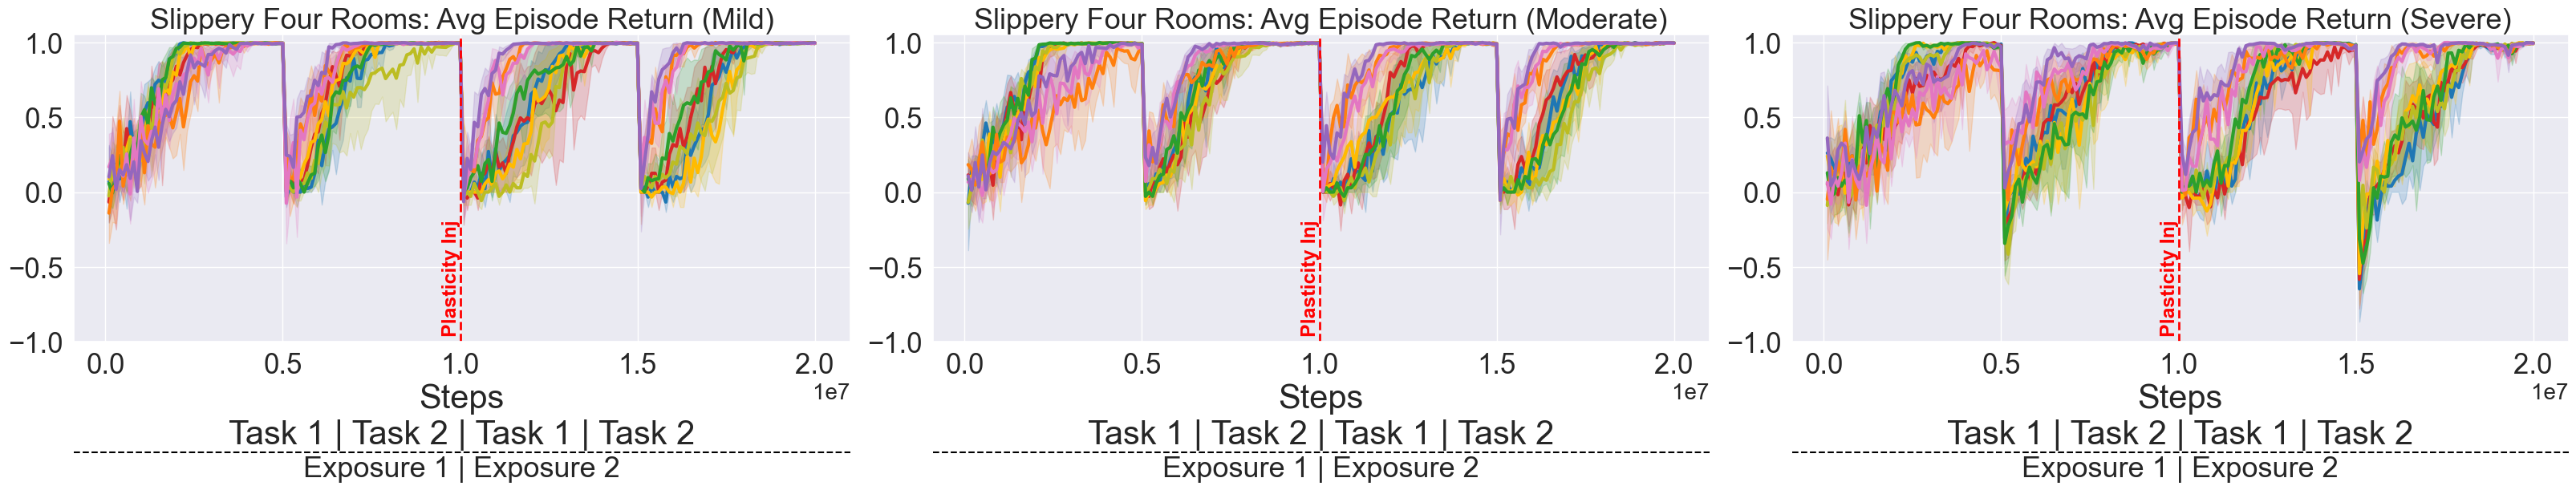

In [100]:
# Comparing with different quantification of mass
fig, axes = plt.subplots(1, 3, figsize=(32, 6), constrained_layout=True)

colors = sns.color_palette("colorblind", 4)

# MILD

sns.lineplot(
    x="eval/steps",
    y="eval/episode_return",
    data=slip_df_mild[slip_df_mild["agent_name"] == agents_new_names["dqn"]],
    label=agents_new_names["dqn"],
    color=color_code[agents_new_names["dqn"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
)

sns.lineplot(
    x="eval/steps",
    y="eval/episode_return",
    data=slip_df_mild[slip_df_mild["agent_name"] == agents_new_names["dqn_cbp"]],
    label=agents_new_names["dqn_cbp"],
    color=color_code[agents_new_names["dqn_cbp"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
)

sns.lineplot(
    x="eval/steps",
    y="eval/episode_return",
    data=slip_df_mild[slip_df_mild["agent_name"] == agents_new_names["DQN_plasticity_injection"]],
    label=agents_new_names["DQN_plasticity_injection"],
    color=color_code[agents_new_names["DQN_plasticity_injection"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5,
    ax=axes[0],
)

sns.lineplot(
    x="eval/steps",
    y="eval/episode_return",
    data=slip_df_mild[slip_df_mild["agent_name"] == agents_new_names["dqn_online_ewc"]],
    label=agents_new_names["dqn_online_ewc"],
    color=color_code[agents_new_names["dqn_online_ewc"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5,
    ax=axes[0],
)

sns.lineplot(
    x="eval/steps",
    y="eval/episode_return",
    data=slip_df_mild[slip_df_mild["agent_name"] == agents_new_names["DQN_consolidation_params_continuous"]],
    label=agents_new_names["DQN_consolidation_params_continuous"],
    color=color_code[agents_new_names["DQN_consolidation_params_continuous"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5,
    ax=axes[0],
)

sns.lineplot(
    x="eval/steps",
    y="eval/episode_return",
    data=slip_df_mild[slip_df_mild["agent_name"] == agents_new_names["simple_sf_agent"]],
    label=agents_new_names["simple_sf_agent"],
    color=color_code[agents_new_names["simple_sf_agent"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
)

sns.lineplot(
    x="eval/steps",
    y="eval/episode_return",
    data=slip_df_mild[slip_df_mild["agent_name"] == agents_new_names["simple_sf_online_ewc"]],
    label=agents_new_names["simple_sf_online_ewc"],
    color=color_code[agents_new_names["simple_sf_online_ewc"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
)

sns.lineplot(
    x="eval/steps",
    y="eval/episode_return",
    data=slip_df_mild[slip_df_mild["agent_name"] == agents_new_names["sf_consolidation_params_continuous"]],
    label=agents_new_names["sf_consolidation_params_continuous"],
    color=color_code[agents_new_names["sf_consolidation_params_continuous"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
)

# MODERATE

sns.lineplot(
    x="eval/steps",
    y="eval/episode_return",
    data=slip_df_moderate[slip_df_moderate["agent_name"] == agents_new_names["dqn"]],
    label=agents_new_names["dqn"],
    color=color_code[agents_new_names["dqn"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[1],
)

sns.lineplot(
    x="eval/steps",
    y="eval/episode_return",
    data=slip_df_moderate[slip_df_moderate["agent_name"] == agents_new_names["dqn_cbp"]],
    label=agents_new_names["dqn_cbp"],
    color=color_code[agents_new_names["dqn_cbp"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[1],
)

sns.lineplot(
    x="eval/steps",
    y="eval/episode_return",
    data=slip_df_moderate[slip_df_moderate["agent_name"] == agents_new_names["DQN_plasticity_injection"]],
    label=agents_new_names["DQN_plasticity_injection"],
    color=color_code[agents_new_names["DQN_plasticity_injection"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5,
    ax=axes[1],
)

sns.lineplot(
    x="eval/steps",
    y="eval/episode_return",
    data=slip_df_moderate[slip_df_moderate["agent_name"] == agents_new_names["dqn_online_ewc"]],
    label=agents_new_names["dqn_online_ewc"],
    color=color_code[agents_new_names["dqn_online_ewc"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5,
    ax=axes[1],
)

sns.lineplot(
    x="eval/steps",
    y="eval/episode_return",
    data=slip_df_moderate[slip_df_moderate["agent_name"] == agents_new_names["DQN_consolidation_params_continuous"]],
    label=agents_new_names["DQN_consolidation_params_continuous"],
    color=color_code[agents_new_names["DQN_consolidation_params_continuous"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5,
    ax=axes[1],
)

sns.lineplot(
    x="eval/steps",
    y="eval/episode_return",
    data=slip_df_moderate[slip_df_moderate["agent_name"] == agents_new_names["simple_sf_agent"]],
    label=agents_new_names["simple_sf_agent"],
    color=color_code[agents_new_names["simple_sf_agent"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[1],
)

sns.lineplot(
    x="eval/steps",
    y="eval/episode_return",
    data=slip_df_moderate[slip_df_moderate["agent_name"] == agents_new_names["simple_sf_online_ewc"]],
    label=agents_new_names["simple_sf_online_ewc"],
    color=color_code[agents_new_names["simple_sf_online_ewc"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[1],
)

sns.lineplot(
    x="eval/steps",
    y="eval/episode_return",
    data=slip_df_moderate[slip_df_moderate["agent_name"] == agents_new_names["sf_consolidation_params_continuous"]],
    label=agents_new_names["sf_consolidation_params_continuous"],
    color=color_code[agents_new_names["sf_consolidation_params_continuous"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[1],
)

# SEVERE

sns.lineplot(
    x="eval/steps",
    y="eval/episode_return",
    data=slip_df_severe[slip_df_severe["agent_name"] == agents_new_names["dqn"]],
    label=agents_new_names["dqn"],
    color=color_code[agents_new_names["dqn"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[2],
)

sns.lineplot(
    x="eval/steps",
    y="eval/episode_return",
    data=slip_df_severe[slip_df_severe["agent_name"] == agents_new_names["dqn_cbp"]],
    label=agents_new_names["dqn_cbp"],
    color=color_code[agents_new_names["dqn_cbp"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[2],
)

sns.lineplot(
    x="eval/steps",
    y="eval/episode_return",
    data=slip_df_severe[slip_df_severe["agent_name"] == agents_new_names["DQN_plasticity_injection"]],
    label=agents_new_names["DQN_plasticity_injection"],
    color=color_code[agents_new_names["DQN_plasticity_injection"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5,
    ax=axes[2],
)

sns.lineplot(
    x="eval/steps",
    y="eval/episode_return",
    data=slip_df_severe[slip_df_severe["agent_name"] == agents_new_names["dqn_online_ewc"]],
    label=agents_new_names["dqn_online_ewc"],
    color=color_code[agents_new_names["dqn_online_ewc"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5,
    ax=axes[2],
)

sns.lineplot(
    x="eval/steps",
    y="eval/episode_return",
    data=slip_df_severe[slip_df_severe["agent_name"] == agents_new_names["DQN_consolidation_params_continuous"]],
    label=agents_new_names["DQN_consolidation_params_continuous"],
    color=color_code[agents_new_names["DQN_consolidation_params_continuous"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5,
    ax=axes[2],
)

sns.lineplot(
    x="eval/steps",
    y="eval/episode_return",
    data=slip_df_severe[slip_df_severe["agent_name"] == agents_new_names["simple_sf_agent"]],
    label=agents_new_names["simple_sf_agent"],
    color=color_code[agents_new_names["simple_sf_agent"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[2],
)

sns.lineplot(
    x="eval/steps",
    y="eval/episode_return",
    data=slip_df_severe[slip_df_severe["agent_name"] == agents_new_names["simple_sf_online_ewc"]],
    label=agents_new_names["simple_sf_online_ewc"],
    color=color_code[agents_new_names["simple_sf_online_ewc"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[2],
)

sns.lineplot(
    x="eval/steps",
    y="eval/episode_return",
    data=slip_df_severe[slip_df_severe["agent_name"] == agents_new_names["sf_consolidation_params_continuous"]],
    label=agents_new_names["sf_consolidation_params_continuous"],
    color=color_code[agents_new_names["sf_consolidation_params_continuous"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[2],
)
xline = 1e7

axes[0].set_ylim(-1.0, 1.05)
ymin, ymax = axes[0].get_ylim()
axes[0].axvline(x=xline, color="red", linestyle="--", linewidth=2)
axes[0].text(
    xline,                      # x position (same as line)
    ymin + 0.4 * (ymax - ymin),   # 40% above the bottom,
    "Plasticity Inj",
    rotation=90,                # vertical text
    color="red",
    ha="right", va="top",       # horizontal/vertical alignment
    fontsize=18,
    fontweight="bold"
)

axes[0].text(
    0.5, -0.25,
    "Task 1 | Task 2 | Task 1 | Task 2",
    transform=axes[0].transAxes,
    ha="center", va="top", fontsize=30
)

axes[0].hlines(
    y=-0.36, xmin=0, xmax=1,
    colors="black", linestyles="--", linewidth=1.5,
    transform=axes[0].transAxes, clip_on=False
)

axes[0].text(
    0.5, -0.37,
    "Exposure 1 | Exposure 2",
    transform=axes[0].transAxes,
    ha="center", va="top", fontsize=26
)

axes[1].set_ylim(-1.0, 1.05)
ymin, ymax = axes[1].get_ylim()
axes[1].axvline(x=xline, color="red", linestyle="--", linewidth=2)
axes[1].text(
    xline,                      # x position (same as line)
    ymin + 0.4 * (ymax - ymin),   # 40% above the bottom,
    "Plasticity Inj",
    rotation=90,                # vertical text
    color="red",
    ha="right", va="top",       # horizontal/vertical alignment
    fontsize=18,
    fontweight="bold"
)

axes[1].text(
    0.5, -0.25,
    "Task 1 | Task 2 | Task 1 | Task 2",
    transform=axes[1].transAxes,
    ha="center", va="top", fontsize=30
)

axes[1].hlines(
    y=-0.36, xmin=0, xmax=1,
    colors="black", linestyles="--", linewidth=1.5,
    transform=axes[1].transAxes, clip_on=False
)

axes[1].text(
    0.5, -0.37,
    "Exposure 1 | Exposure 2",
    transform=axes[1].transAxes,
    ha="center", va="top", fontsize=26
)

axes[2].set_ylim(-1.0, 1.05)
ymin, ymax = axes[2].get_ylim()
axes[2].axvline(x=xline, color="red", linestyle="--", linewidth=2)
axes[2].text(
    xline,                      # x position (same as line)
    ymin + 0.4 * (ymax - ymin),   # 40% above the bottom,
    "Plasticity Inj",
    rotation=90,                # vertical text
    color="red",
    ha="right", va="top",       # horizontal/vertical alignment
    fontsize=18,
    fontweight="bold"
)

axes[2].text(
    0.5, -0.25,
    "Task 1 | Task 2 | Task 1 | Task 2",
    transform=axes[2].transAxes,
    ha="center", va="top", fontsize=30
)

axes[2].hlines(
    y=-0.36, xmin=0, xmax=1,
    colors="black", linestyles="--", linewidth=1.5,
    transform=axes[2].transAxes, clip_on=False
)

axes[2].text(
    0.5, -0.37,
    "Exposure 1 | Exposure 2",
    transform=axes[2].transAxes,
    ha="center", va="top", fontsize=26
)

axes[0].set_title("Slippery Four Rooms: Avg Episode Return (Mild)", fontsize=26)
axes[0].set_xlabel("Steps", fontsize=30)
axes[0].set_ylabel("", fontsize=30)
# axes[0].legend(loc="upper left", fontsize=20)
axes[0].tick_params(axis="x", labelsize=25)
axes[0].tick_params(axis="y", labelsize=25)
axes[0].xaxis.get_offset_text().set_fontsize(20)
axes[0].legend().set_visible(False)
axes[0].xaxis.set_major_locator(MaxNLocator(5))
# axes[0].set_ylim(-1.0, 1.05)
axes[0].set_yticks([-1.0, -0.5, 0.0, 0.5, 1.0])

axes[1].set_title("Slippery Four Rooms: Avg Episode Return (Moderate)", fontsize=26)
axes[1].set_xlabel("Steps", fontsize=30)
axes[1].set_ylabel("", fontsize=30)
# axes[1].legend(loc="upper left", fontsize=20)
axes[1].tick_params(axis="x", labelsize=25)
axes[1].tick_params(axis="y", labelsize=25)
axes[1].xaxis.get_offset_text().set_fontsize(20)
axes[1].legend().set_visible(False)
axes[1].xaxis.set_major_locator(MaxNLocator(5))
# axes[1].set_ylim(-1.0, 1.05)
axes[1].set_yticks([-1.0, -0.5, 0.0, 0.5, 1.0])

axes[2].set_title("Slippery Four Rooms: Avg Episode Return (Severe)", fontsize=26)
axes[2].set_xlabel("Steps", fontsize=30)
axes[2].set_ylabel("", fontsize=30)
# axes[2].legend(loc="upper left", fontsize=20)
axes[2].tick_params(axis="x", labelsize=25)
axes[2].tick_params(axis="y", labelsize=25)
axes[2].xaxis.get_offset_text().set_fontsize(20)
axes[2].legend().set_visible(False)
axes[2].xaxis.set_major_locator(MaxNLocator(5))
# axes[2].set_ylim(-1.0, 1.05)
axes[2].set_yticks([-1.0, -0.5, 0.0, 0.5, 1.0])

filename = "slip_analysis_avg_episode_return"
plt.savefig(filename + ".pdf")
plt.show()

Index(['run_idx', 'run_name', 'agent_name', 'domain_slippery_prob', 'task',
       'threshold', 'first_below_global', 'first_below_local', 'Agent',
       'task_label'],
      dtype='object')


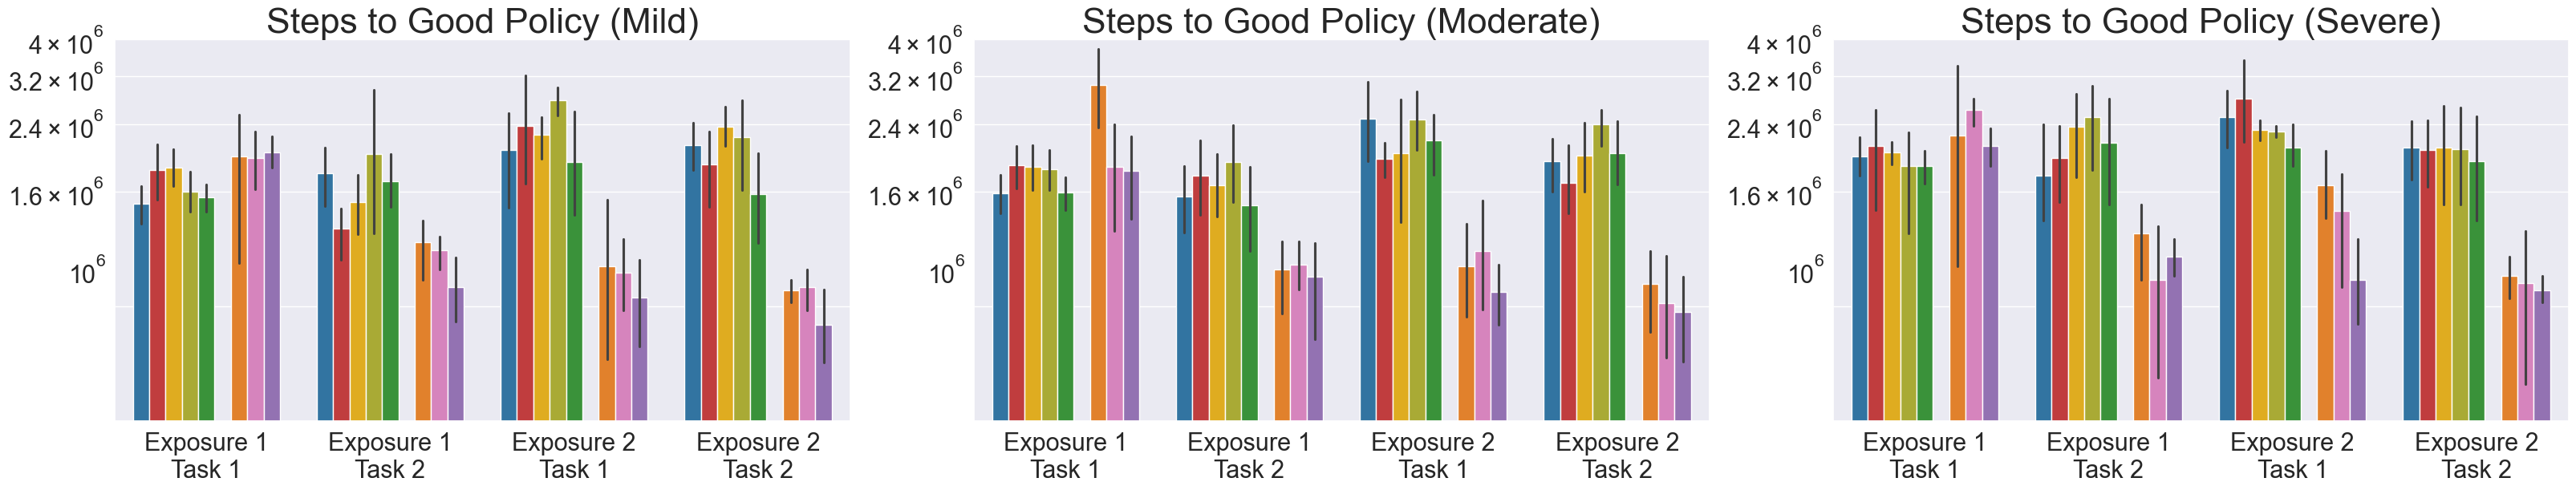

In [99]:
fig, axes = plt.subplots(1, 3, figsize=(32, 6), constrained_layout=True)

rows = []
threshold = 1000
aggregate_across_runs = True  # set True to average across runs/seeds
num_train_steps_per_task = 5000000

agent_order = [
    "DQN",
    "DQN + CBP",
    "DQN + P-last",
    "DQN + EWC",
    "DQN + SC",
    " ",
    "SF",
    "SF + EWC",
    "SF + SC (Ours)",
]

task_labels = {
    0: "Exposure 1\nTask 1",
    1: "Exposure 1\nTask 2",
    2: "Exposure 2\nTask 1",
    3: "Exposure 2\nTask 2",
}

for run_idx, (temp, cfg, name) in enumerate(zip(summary_list, config_list, name_list)):
    steps = np.asarray(temp["eval/steps"])
    tasks = np.asarray(temp["train/task"])
    mavg = np.asarray(temp["eval/avg_episode_length"])

    # Sanity check: lengths should match
    L = min(len(steps), len(tasks), len(mavg))
    steps, tasks, mavg = steps[:L], tasks[:L], mavg[:L]

    for task_id in np.unique(tasks):
        idxs = np.where(tasks == task_id)[0]
        if idxs.size == 0:
            continue

        # earliest idx within this task where condition is true
        hit_mask = mavg[idxs] < threshold
        if hit_mask.any():
            first_idx = idxs[np.argmax(hit_mask)]  # index in the *full* arrays
            global_step = steps[first_idx]
            local_step = global_step - task_id * num_train_steps_per_task

        else:
            first_idx = None
            global_step = np.nan
            local_step = np.nan

        rows.append({
            "run_idx": run_idx,
            "run_name": name,
            "agent_name": cfg.get("agent_name", f"run{run_idx}"),
            "domain_slippery_prob": cfg.get("domain_slippery_prob", 0),
            "task": task_id,
            "threshold": threshold,
            "first_below_global": global_step,
            "first_below_local": local_step,   # << use this for plotting
        })

df_hits = pd.DataFrame(rows)
df_hits["Agent"] = df_hits["agent_name"].map(agents_new_names)
df_hits["task_label"] = df_hits["task"].map(task_labels)
palette = {name: color_code[name] for name in df_hits["Agent"].unique() if name in color_code}
palette_with_space = palette.copy()
palette_with_space[" "] = (0, 0, 0, 0)   # transparent color

# Optional: ensure tasks are ordered nicely (0..3 or custom)
# df_hits["task"] = pd.Categorical(df_hits["task"], ordered=True)

df_hits_mild = df_hits[df_hits['domain_slippery_prob'] == 0.1125]

df_hits_moderate = df_hits[df_hits['domain_slippery_prob'] == 0.225]

df_hits_severe = df_hits[df_hits['domain_slippery_prob'] == 0.45]

x_order = ["Exposure 1\nTask 1", "Exposure 1\nTask 2",
           "Exposure 2\nTask 1", "Exposure 2\nTask 2"]

# print column names
print(df_hits.columns)

# === Plotting ===
sns.barplot(
    data=df_hits_mild,
    x="task_label",
    y="first_below_local",
    hue="Agent",
    dodge=True,
    estimator="mean",   # now mean per agent_name per task
    errorbar="ci",
    palette=palette_with_space,
    hue_order=agent_order,
    ax=axes[0],
)

sns.barplot(
    data=df_hits_moderate,
    x="task_label",
    y="first_below_local",
    hue="Agent",
    dodge=True,
    estimator="mean",   # now mean per agent_name per task
    errorbar="ci",
    palette=palette_with_space,
    hue_order=agent_order,
    ax=axes[1],
)

sns.barplot(
    data=df_hits_severe,
    x="task_label",
    y="first_below_local",
    hue="Agent",
    dodge=True,
    estimator="mean",   # now mean per agent_name per task
    errorbar="ci",
    palette=palette_with_space,
    hue_order=agent_order,
    ax=axes[2],
)

axes[0].yaxis.get_offset_text().set_visible(False)
axes[0].set_xlabel("")
axes[0].set_ylabel("")
axes[0].set_title("Steps to Good Policy (Mild)", fontsize=32)
axes[0].set_yscale("log")
axes[0].tick_params(axis="x", labelsize=22)
axes[0].tick_params(axis="y", labelsize=22, which="both")
axes[0].yaxis.set_major_locator(MaxNLocator(nbins=5))
axes[0].yaxis.set_minor_locator(LogLocator(base=10.0, subs=[]))
axes[0].legend().set_visible(False)
axes[0].set_ylim(top=4 * (10**6), bottom=4 * (10**5))

axes[1].yaxis.get_offset_text().set_visible(False)
axes[1].set_xlabel("")
axes[1].set_ylabel("")
axes[1].set_title("Steps to Good Policy (Moderate)", fontsize=32)
axes[1].set_yscale("log")
axes[1].tick_params(axis="x", labelsize=22)
axes[1].tick_params(axis="y", labelsize=22, which="both")
axes[1].yaxis.set_major_locator(MaxNLocator(nbins=5))
axes[1].yaxis.set_minor_locator(LogLocator(base=10.0, subs=[]))
axes[1].legend().set_visible(False)# no minor ticks
axes[1].set_ylim(top=4 * (10**6), bottom=4 * (10**5))


axes[2].yaxis.get_offset_text().set_visible(False)
axes[2].set_xlabel("")
axes[2].set_ylabel("")
axes[2].set_title("Steps to Good Policy (Severe)", fontsize=32)
axes[2].set_yscale("log")
axes[2].tick_params(axis="x", labelsize=22)
axes[2].tick_params(axis="y", labelsize=22, which="both")
axes[2].yaxis.set_major_locator(MaxNLocator(nbins=5))
axes[2].yaxis.set_minor_locator(LogLocator(base=10.0, subs=[]))
axes[2].legend().set_visible(False)# no minor ticks
axes[2].set_ylim(top=4 * (10**6), bottom=4 * (10**5))

filename = "slippery_analysis_steps_to_good_policy"
plt.savefig(filename + ".pdf")
plt.show()

In [129]:
from scipy.integrate import trapezoid

def compute_auc(group):
    return trapezoid(group["eval/episode_return"], group["eval/steps"])
auc_df = (
    runs_df.groupby(["agent_name", "agent_seed", "domain_slippery_prob"], group_keys=False)
      .apply(compute_auc, include_groups=False)
      .reset_index(name="AUC")
)

auc_df_mild = auc_df[auc_df['domain_slippery_prob'] == 0.1125]

auc_df_moderate = auc_df[auc_df['domain_slippery_prob'] == 0.225]

auc_df_severe = auc_df[auc_df['domain_slippery_prob'] == 0.45]

print(auc_df_mild.head())

   agent_name  agent_seed  domain_slippery_prob           AUC
2         DQN         194                0.1125  1.337023e+07
4         DQN         291                0.1125  1.381930e+07
6         DQN         388                0.1125  1.426840e+07
9         DQN         485                0.1125  1.307676e+07
12        DQN         582                0.1125  1.339203e+07


In [132]:
agents_to_plot = ["DQN", "DQN + CBP", "DQN + EWC", "DQN + P-last", "DQN + SC", "SF", "SF + EWC", "SF + SC (Ours)",]
auc_df_mild = auc_df_mild[auc_df_mild["agent_name"].isin(agents_to_plot)]
auc_df_moderate = auc_df_moderate[auc_df_moderate["agent_name"].isin(agents_to_plot)]
auc_df_severe = auc_df_severe[auc_df_severe["agent_name"].isin(agents_to_plot)]

In [133]:
auc_df_mild["agent_name_pretty"] = auc_df_mild["agent_name"].str.replace(" + ", "\n +", regex=False)
auc_df_mild["agent_name_pretty"] = auc_df_mild["agent_name_pretty"].str.replace(
    "SF\n +SC (Ours)", "SF\n +SC \n(Ours)", regex=False
)

auc_df_moderate["agent_name_pretty"] = auc_df_moderate["agent_name"].str.replace(" + ", "\n +", regex=False)
auc_df_moderate["agent_name_pretty"] = auc_df_moderate["agent_name_pretty"].str.replace(
    "SF\n +SC (Ours)", "SF\n +SC \n(Ours)", regex=False
)

auc_df_severe["agent_name_pretty"] = auc_df_severe["agent_name"].str.replace(" + ", "\n +", regex=False)
auc_df_severe["agent_name_pretty"] = auc_df_severe["agent_name_pretty"].str.replace(
    "SF\n +SC (Ours)", "SF\n +SC \n(Ours)", regex=False
)


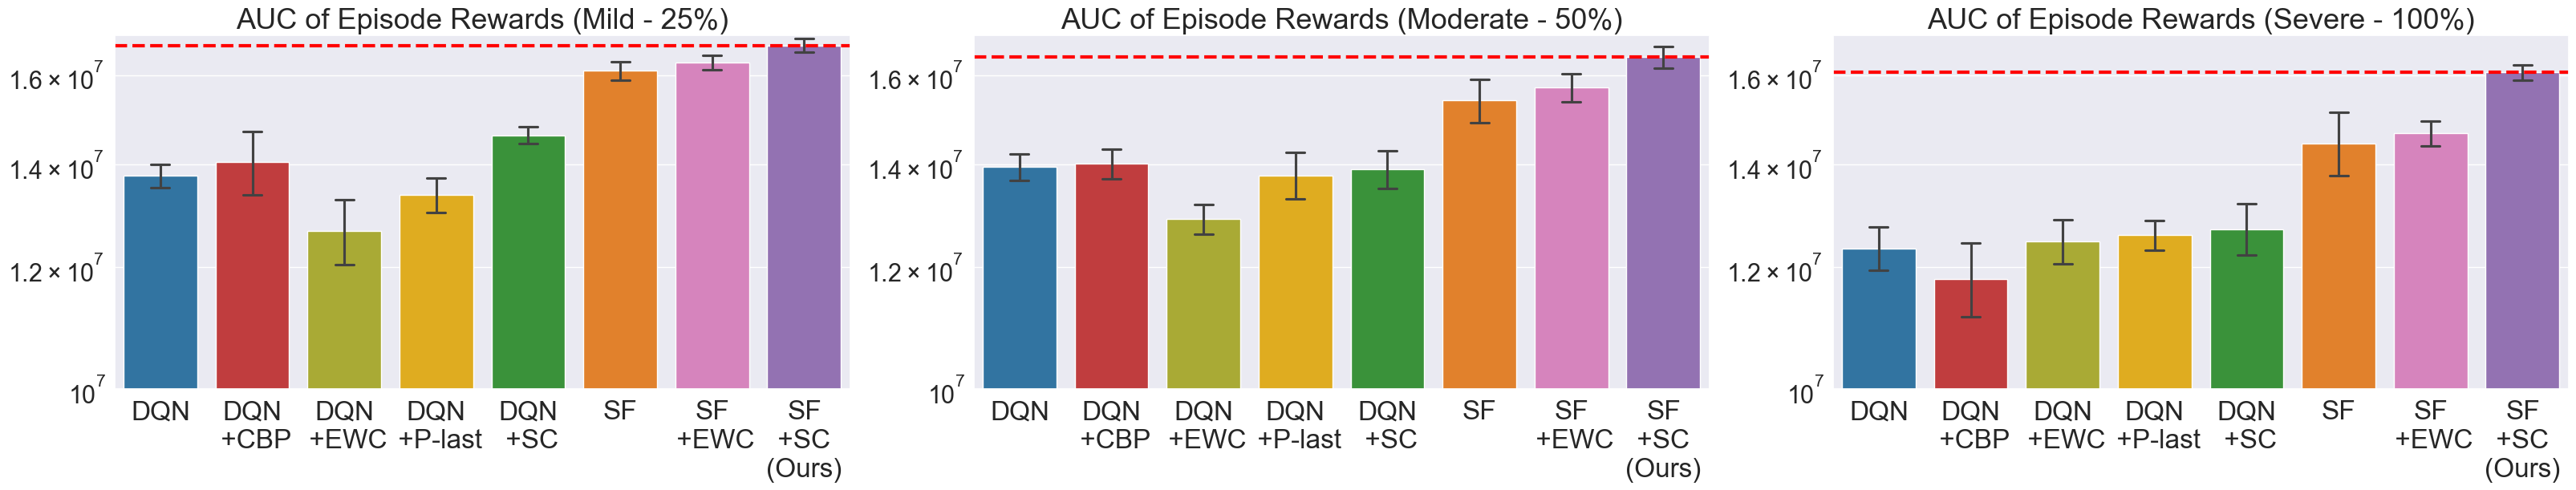

In [140]:
fig, axes = plt.subplots(1, 3, figsize=(32, 6), constrained_layout=True)

ax_mild = sns.barplot(data=auc_df_mild, x="agent_name_pretty", y="AUC", palette=color_code, errorbar="se", capsize=0.2, hue="agent_name_pretty", ax=axes[0])

ax_moderate = sns.barplot(data=auc_df_moderate, x="agent_name_pretty", y="AUC", palette=color_code, errorbar="se", capsize=0.2, hue="agent_name_pretty", ax=axes[1])

ax_severe = sns.barplot(data=auc_df_severe, x="agent_name_pretty", y="AUC", palette=color_code, errorbar="se", capsize=0.2, hue="agent_name_pretty", ax=axes[2])

mean_val_mild = auc_df_mild[auc_df_mild["agent_name"] == agents_new_names["sf_consolidation_params_continuous"]]["AUC"].mean()
ax_mild.axhline(mean_val_mild, color="red", linestyle="--", linewidth=3)

mean_val_moderate = auc_df_moderate[auc_df_moderate["agent_name"] == agents_new_names["sf_consolidation_params_continuous"]]["AUC"].mean()
ax_moderate.axhline(mean_val_moderate, color="red", linestyle="--", linewidth=3)

mean_val_severe = auc_df_severe[auc_df_severe["agent_name"] == agents_new_names["sf_consolidation_params_continuous"]]["AUC"].mean()
ax_severe.axhline(mean_val_severe, color="red", linestyle="--", linewidth=3)


axes[0].set_xlabel("", fontsize=14)
axes[0].set_ylabel("", fontsize=14)
axes[0].set_title("AUC of Episode Rewards (Mild - 25%)", fontsize=26)
axes[0].tick_params(axis="x", labelsize=24)
axes[0].tick_params(axis="y", labelsize=28)
axes[0].set_yscale("log")
axes[0].yaxis.set_major_locator(MaxNLocator(nbins=3))
axes[0].yaxis.set_minor_locator(LogLocator(base=10.0, subs=[]))
axes[0].tick_params(axis='y', which='both', labelsize=22)
axes[0].yaxis.get_offset_text().set_visible(False)
axes[0].set_yticks([1.2 * (10**7), 1.4 * (10**7), 1.6 * (10**7)])
axes[0].set_ylim(1.0 * (10**7), 1.7 * (10**7))

axes[1].set_xlabel("", fontsize=14)
axes[1].set_ylabel("", fontsize=14)
axes[1].set_title("AUC of Episode Rewards (Moderate - 50%)", fontsize=26)
axes[1].tick_params(axis="x", labelsize=24)
axes[1].tick_params(axis="y", labelsize=28)
axes[1].set_yscale("log")
axes[1].yaxis.set_major_locator(MaxNLocator(nbins=3))
axes[1].yaxis.set_minor_locator(LogLocator(base=10.0, subs=[]))
axes[1].tick_params(axis='y', which='both', labelsize=22)
axes[1].yaxis.get_offset_text().set_visible(False)
axes[1].set_yticks([1.2 * (10**7), 1.4 * (10**7), 1.6 * (10**7)])
axes[1].set_ylim(1.0 * (10**7), 1.7 * (10**7))

axes[2].set_xlabel("", fontsize=14)
axes[2].set_ylabel("", fontsize=14)
axes[2].set_title("AUC of Episode Rewards (Severe - 100%)", fontsize=26)
axes[2].tick_params(axis="x", labelsize=24)
axes[2].tick_params(axis="y", labelsize=28)
axes[2].set_yscale("log")
axes[2].yaxis.set_major_locator(MaxNLocator(nbins=3))
axes[2].yaxis.set_minor_locator(LogLocator(base=10.0, subs=[]))
axes[2].tick_params(axis='y', which='both', labelsize=22)
axes[2].yaxis.get_offset_text().set_visible(False)
axes[2].set_yticks([1.2 * (10**7), 1.4 * (10**7), 1.6 * (10**7)])
axes[2].set_ylim(1.0 * (10**7), 1.7 * (10**7))

filename = "slippery_analysis_auc"
plt.savefig(filename + ".pdf")
plt.show()


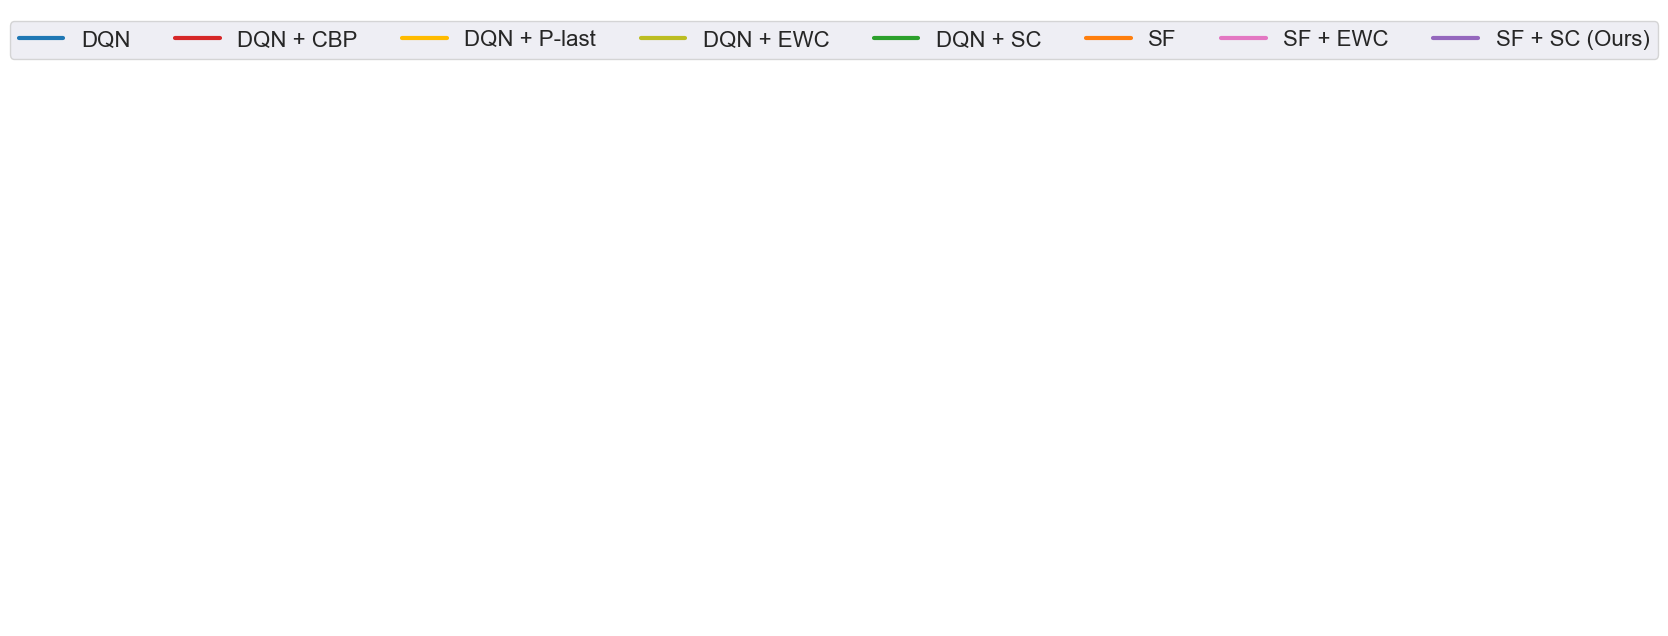

In [146]:
"""
This plot is only used for making legends!!!!
"""

from matplotlib.lines import Line2D

custom_lines = [
    Line2D([0], [0], color=color_code[agents_new_names["dqn"]], lw=3, label=agents_new_names["dqn"]),
    Line2D([0], [0], color=color_code[agents_new_names["dqn_cbp"]], lw=3, label=agents_new_names["dqn_cbp"]),
    Line2D([0], [0], color=color_code[agents_new_names["DQN_plasticity_injection"]], lw=3, label=agents_new_names["DQN_plasticity_injection"]),
    Line2D([0], [0], color=color_code[agents_new_names["dqn_online_ewc"]], lw=3, label=agents_new_names["dqn_online_ewc"]),
    Line2D([0], [0], color=color_code[agents_new_names["DQN_consolidation_params_continuous"]], lw=3, label=agents_new_names["DQN_consolidation_params_continuous"]),
    Line2D([0], [0], color=color_code[agents_new_names["simple_sf_agent"]], lw=3, label=agents_new_names["simple_sf_agent"]),
    Line2D([0], [0], color=color_code[agents_new_names["simple_sf_online_ewc"]], lw=3, label=agents_new_names["simple_sf_online_ewc"]),
    Line2D([0], [0], color=color_code[agents_new_names["sf_consolidation_params_continuous"]], lw=3, label=agents_new_names["sf_consolidation_params_continuous"]),
]

fig, ax = plt.subplots(figsize=(16, 8))
ax.axis("off")               # hide axes
plt.legend(
    handles=custom_lines,
    loc="upper center",          # center horizontally
    bbox_to_anchor=(0.5, 1),
    fontsize=16,
    ncol=8                       # optional: make legend entries spread in columns
)

filename = "slippery_four_rooms_make_title"
fig.savefig(filename + ".pdf")
plt.show()
